# Project 3: Word Embeddings

This notebook builds word/document embeddings with **TF-IDF** (term
frequency-inverse document frequency) and then reduces their
dimensionality with **Principal Component Analysis (PCA)**, so that the
most important variance (information) in the embeddings is preserved
while most of the raw feature axes are discarded.

Every table, number, and plot below is produced by the code cells in
this notebook, so re-running **Cell &#9656; Run All** reproduces the
entire assignment end to end. Only NumPy (linear algebra) and
Matplotlib (the final plot) are used as dependencies.

## Part A: From Text to Vectors -- TF-IDF

### A.1 Why TF-IDF

A word embedding needs to turn text into numbers before any linear
algebra (like PCA) can be applied to it. **TF-IDF** is one of the
simplest and most widely used ways to do this: it represents each
*document* as a vector over the vocabulary, where each coordinate says
how important a given word is to that document, relative to the whole
corpus.

### A.2 The formula

For term $t$ and document $d$ in a corpus of $N$ documents:

$$\text{TF}(t,d) = \frac{\text{count of } t \text{ in } d}{\text{number of terms in } d}$$

$$\text{IDF}(t) = \ln\!\left(\frac{1+N}{1+\text{DF}(t)}\right) + 1 \qquad \text{(smoothed IDF)}$$

$$\text{TFIDF}(t,d) = \text{TF}(t,d)\cdot\text{IDF}(t)$$

where $\text{DF}(t)$ is the number of documents containing term $t$ at
least once. `TF` measures local importance (how often a word is used
*in this document*); `IDF` down-weights words that appear in almost
every document (common, low-information words) and up-weights words
that are rare across the corpus (distinctive, high-information words).
The `+1` smoothing in `IDF` prevents division by zero when
$\text{DF}(t)=N$ and matches the convention used by scikit-learn's
`TfidfVectorizer` (see Citations at the end of this notebook).

Each document therefore becomes a vector in $\mathbb{R}^V$, where $V$
is the vocabulary size -- this is the "embedding" we hand to PCA.

### A.3 Worked example corpus

To make the computation concrete, we use a 9-document corpus covering
three topics (3 documents each), with basic English stop words
(`the`, `and`, `to`, ...) removed before vectorizing.

In [1]:
import numpy as np

np.set_printoptions(suppress=True, linewidth=200)

CORPUS = [
    "the dog chased the cat around the yard",           # d1 - animals
    "the cat sat quietly while the dog barked",         # d2 - animals
    "dogs and cats often play together in the yard",    # d3 - animals
    "the car engine roared down the highway",           # d4 - cars
    "she drove her new car to the highway",             # d5 - cars
    "the mechanic fixed the car engine quickly",        # d6 - cars
    "the chef cooked pasta with fresh tomato sauce",    # d7 - cooking
    "fresh tomato sauce makes the pasta taste great",   # d8 - cooking
    "the recipe calls for fresh basil and tomato sauce",  # d9 - cooking
]

LABELS = ["animals"] * 3 + ["cars"] * 3 + ["cooking"] * 3

STOPWORDS = {
    "the", "and", "in", "with", "to", "her", "on", "while", "often",
    "together", "for", "makes", "quickly", "down", "around", "near",
    "quietly", "calls", "she",
}

for i, (doc, label) in enumerate(zip(CORPUS, LABELS), start=1):
    print(f"d{i:<2} [{label:<7}] {doc}")

d1  [animals] the dog chased the cat around the yard
d2  [animals] the cat sat quietly while the dog barked
d3  [animals] dogs and cats often play together in the yard
d4  [cars   ] the car engine roared down the highway
d5  [cars   ] she drove her new car to the highway
d6  [cars   ] the mechanic fixed the car engine quickly
d7  [cooking] the chef cooked pasta with fresh tomato sauce
d8  [cooking] fresh tomato sauce makes the pasta taste great
d9  [cooking] the recipe calls for fresh basil and tomato sauce


In [2]:
def tokenize(doc):
    return [w for w in doc.lower().split() if w not in STOPWORDS]


def build_tfidf_matrix(corpus):
    tokenized = [tokenize(d) for d in corpus]
    vocab = sorted({w for doc in tokenized for w in doc})
    vocab_index = {w: i for i, w in enumerate(vocab)}
    n_docs, n_terms = len(corpus), len(vocab)

    # Term frequency: count of term t in document d, divided by doc length
    tf = np.zeros((n_docs, n_terms))
    for d, doc in enumerate(tokenized):
        for w in doc:
            tf[d, vocab_index[w]] += 1.0
        if len(doc) > 0:
            tf[d, :] /= len(doc)

    # Document frequency: number of documents containing term t
    df = np.count_nonzero(tf > 0, axis=0)

    # Inverse document frequency (smoothed, matches scikit-learn's default):
    # idf(t) = ln((1 + N) / (1 + df(t))) + 1
    idf = np.log((1.0 + n_docs) / (1.0 + df)) + 1.0

    tfidf = tf * idf
    return tfidf, vocab, idf


tfidf, vocab, idf = build_tfidf_matrix(CORPUS)
print(f"vocabulary size: {len(vocab)} terms")
print(f"TF-IDF matrix shape: {tfidf.shape}  (documents x terms)\n")

print(f"{'term':<10} {'idf':>8}")
for w, v in zip(vocab, idf):
    print(f"{w:<10} {v:>8.4f}")

vocabulary size: 27 terms
TF-IDF matrix shape: (9, 27)  (documents x terms)

term            idf
barked       2.6094
basil        2.6094
car          1.9163
cat          2.2040
cats         2.6094
chased       2.6094
chef         2.6094
cooked       2.6094
dog          2.2040
dogs         2.6094
drove        2.6094
engine       2.2040
fixed        2.6094
fresh        1.9163
great        2.6094
highway      2.2040
mechanic     2.6094
new          2.6094
pasta        2.2040
play         2.6094
recipe       2.6094
roared       2.6094
sat          2.6094
sauce        1.9163
taste        2.6094
tomato       1.9163
yard         2.2040


Notice the effect described above directly in the IDF weights: `car`
and `fresh` each appear in 3 of the 9 documents (all documents of their
own topic) and get a lower IDF (`1.9163`), while `basil` appears in
only 1 of the 9 documents and gets the *highest* IDF (`2.6094`) -- it
is the most distinctive/rare word in the corpus.

In [3]:
print("Full TF-IDF matrix (documents x terms):\n")
header = f"{'doc':<5}{'topic':<9}" + "".join(f"{w[:6]:>7}" for w in vocab)
print(header)
for i, row in enumerate(tfidf):
    vals = "".join(f"{v:>7.3f}" for v in row)
    print(f"d{i+1:<4}{LABELS[i]:<9}{vals}")

Full TF-IDF matrix (documents x terms):

doc  topic     barked  basil    car    cat   cats chased   chef cooked    dog   dogs  drove engine  fixed  fresh  great highwa mechan    new  pasta   play recipe roared    sat  sauce  taste tomato   yard
d1   animals    0.000  0.000  0.000  0.551  0.000  0.652  0.000  0.000  0.551  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.551
d2   animals    0.652  0.000  0.000  0.551  0.000  0.000  0.000  0.000  0.551  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.652  0.000  0.000  0.000  0.000
d3   animals    0.000  0.000  0.000  0.000  0.652  0.000  0.000  0.000  0.000  0.652  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.652  0.000  0.000  0.000  0.000  0.000  0.000  0.551
d4   cars       0.000  0.000  0.479  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.551  0.000  0.000  0.000  0.551  0.000  0.000  0

## Part B: Dimensionality Reduction with PCA

Our 9 documents now live in a 27-dimensional TF-IDF space, but most of
that space is empty/redundant (most documents use only a handful of
the 27 words). **PCA finds a small number of new axes -- linear
combinations of the original word-count axes -- that capture as much
of the spread (variance) in the data as possible**, so we can plot or
further process the documents in, say, 2 dimensions with minimal loss
of information.

### B.1 Pseudocode

```
function PCA(X, k):
    # X is an (n_documents x n_features) matrix of embeddings (e.g. TF-IDF)
    # k is the number of dimensions to keep

    # 1. Mean and centering
    mean = column_wise_average(X)              # shape: (n_features,)
    X_centered = X - mean                       # subtract mean from every row

    # 2. Covariance matrix
    # measures how every pair of features varies together across documents
    Cov = (X_centered^T * X_centered) / (n_documents - 1)   # shape: (n_features x n_features)

    # 3. Eigenvalues and eigenvectors of the covariance matrix
    (eigenvalues, eigenvectors) = eigen_decomposition(Cov)
    # Cov is real and symmetric, so eigenvalues are real and
    # eigenvectors are orthogonal

    # 4. Sort eigenpairs by eigenvalue, descending
    order = argsort(eigenvalues, descending=True)
    eigenvalues  = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # 5. Keep the top k eigenvectors (principal components) and project
    top_k_eigenvectors = eigenvectors[:, 0:k]
    X_reduced = X_centered * top_k_eigenvectors  # shape: (n_documents x k)

    explained_variance_ratio = eigenvalues / sum(eigenvalues)

    return X_reduced, eigenvalues, eigenvectors, explained_variance_ratio
```

### B.2 Reference implementation (Python / NumPy)

The code cell below is the exact, runnable equivalent of the
pseudocode above.

In [4]:
def pca(X, n_components):
    n_samples, n_features = X.shape

    # Step 1: mean and centering
    mean = X.mean(axis=0)
    X_centered = X - mean

    # Step 2: covariance matrix (features x features), unbiased (n-1) estimator
    cov = (X_centered.T @ X_centered) / (n_samples - 1)

    # Step 3: eigenvalues/eigenvectors. `cov` is real and symmetric, so we
    # use eigh (not the general eig): faster, numerically stable, and
    # guarantees real eigenvalues/orthogonal eigenvectors.
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Step 4: eigh returns eigenvalues ascending -- reverse to sort
    # descending (most variance first) and reorder the matching eigenvectors
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    explained_variance_ratio = eigenvalues / eigenvalues.sum()

    # Step 5: project onto the top n_components eigenvectors
    components = eigenvectors[:, :n_components]
    X_reduced = X_centered @ components

    return {
        "mean": mean,
        "covariance": cov,
        "eigenvalues": eigenvalues,
        "eigenvectors": eigenvectors,
        "explained_variance_ratio": explained_variance_ratio,
        "X_reduced": X_reduced,
    }


result = pca(tfidf, n_components=2)
print("mean vector shape:", result["mean"].shape)
print("covariance matrix shape:", result["covariance"].shape)
print("\nfirst 8 entries of the mean vector (mean TF-IDF per term):")
for w, m in list(zip(vocab, result["mean"]))[:8]:
    print(f"  {w:<10} {m:.4f}")

mean vector shape: (27,)
covariance matrix shape: (27, 27)

first 8 entries of the mean vector (mean TF-IDF per term):
  barked     0.0725
  basil      0.0580
  car        0.1597
  cat        0.1224
  cats       0.0725
  chased     0.0725
  chef       0.0483
  cooked     0.0483


### B.3 Plain-English explanation of how the code works

1. **Mean and centering.** We first compute the average TF-IDF value
   of each word across all 9 documents (the "mean vector"), then
   subtract it from every document's vector. This shifts the whole
   point cloud so it is centered on the origin. Centering matters
   because covariance and PCA are about how features vary *around
   their average* -- without it, the direction from the origin to the
   average would dominate the covariance and distort the result.

2. **Covariance matrix.** For every pair of words $(i, j)$, the
   covariance matrix entry $\text{Cov}[i, j]$ says whether the two
   words tend to be high or low together across documents (positive
   covariance: they rise and fall together, e.g. `tomato` and `sauce`;
   near-zero covariance: unrelated, e.g. `car` and `basil`). The
   diagonal entries $\text{Cov}[i, i]$ are just the variance of word
   $i$ on its own. This 27x27 matrix summarizes all the pairwise
   co-occurrence structure of the corpus in one object.

3. **Eigenvalues and eigenvectors.** An eigenvector of the covariance
   matrix points in a direction through word-space along which the
   data spreads out; its eigenvalue is *how much* variance the data
   has along that direction. Because the covariance matrix is
   symmetric, all of its eigenvalues are real and its eigenvectors are
   mutually perpendicular (orthogonal) -- they form a new, rotated
   coordinate system for the same data, with no information lost.

4. **Sorting.** We sort the eigenvector/eigenvalue pairs so the
   direction with the *largest* eigenvalue (most variance, i.e. "most
   information") comes first. This is what lets us keep only the
   first $k$ directions and still retain as much of the data's spread
   as possible -- dropping directions with the smallest eigenvalues
   throws away the least information.

5. **Projection.** Multiplying the centered data by the top $k$
   eigenvectors converts each document from a 27-dimensional
   bag-of-words vector into a $k$-dimensional coordinate along the
   most informative axes -- this is the reduced-dimension embedding.

## Part C: Worked Results on the Example Corpus

### C.1 Sorted eigenvalues of the covariance matrix

In [5]:
eigenvalues = result["eigenvalues"]
ratios = result["explained_variance_ratio"]

print(f"{'rank':>4} {'eigenvalue':>12} {'expl. var. %':>14} {'cumulative %':>14}")
cum = 0.0
for i, (val, ratio) in enumerate(zip(eigenvalues, ratios)):
    cum += ratio
    print(f"{i+1:>4} {val:>12.6f} {ratio*100:>13.2f}% {cum*100:>13.2f}%")

rank   eigenvalue   expl. var. %   cumulative %
   1     0.269486         23.82%         23.82%
   2     0.228313         20.18%         43.99%
   3     0.194712         17.21%         61.20%
   4     0.144342         12.76%         73.95%
   5     0.091003          8.04%         82.00%
   6     0.083142          7.35%         89.34%
   7     0.073289          6.48%         95.82%
   8     0.047286          4.18%        100.00%
   9     0.000000          0.00%        100.00%
  10     0.000000          0.00%        100.00%
  11     0.000000          0.00%        100.00%
  12     0.000000          0.00%        100.00%
  13     0.000000          0.00%        100.00%
  14     0.000000          0.00%        100.00%
  15     0.000000          0.00%        100.00%
  16     0.000000          0.00%        100.00%
  17     0.000000          0.00%        100.00%
  18     0.000000          0.00%        100.00%
  19    -0.000000         -0.00%        100.00%
  20    -0.000000         -0.00%        

Only the first 8 eigenvalues are meaningfully non-zero (the rest are
~0 up to floating-point noise). This is expected: with $n=9$ documents,
the centered data matrix has rank at most $n-1=8$ (the rows of any
mean-centered matrix always sum to zero, which removes one degree of
freedom), so the covariance matrix can have at most 8 non-zero
eigenvalues no matter how many word features (27) there are.

Keeping just the **top 2** components retains a large share of the
total variance -- see the cumulative-percent column above -- a big
reduction in dimensionality (27 -> 2) for a modest loss of information.

### C.2 Documents projected onto the top 2 principal components

In [6]:
X_reduced = result["X_reduced"]
print(f"{'doc':<5}{'topic':<9}{'PC1':>10}{'PC2':>10}")
for i, (pc1, pc2) in enumerate(X_reduced):
    print(f"d{i+1:<4}{LABELS[i]:<9}{pc1:>10.4f}{pc2:>10.4f}")

doc  topic           PC1       PC2
d1   animals     -0.6478    0.4551
d2   animals     -0.6145    0.4685
d3   animals     -0.4031    0.1395
d4   cars         0.6773    0.2961
d5   cars         0.6009    0.2540
d6   cars         0.6009    0.2540
d7   cooking     -0.0698   -0.6070
d8   cooking     -0.0698   -0.6070
d9   cooking     -0.0740   -0.6534


Even without ever telling PCA which document belongs to which topic,
the 2-D projection cleanly separates the three topics: **cars** land at
PC1 > 0, **animals** at PC1 < 0 with PC2 > 0, and **cooking** at PC2 <
0. This is the payoff of dimensionality reduction: 27 sparse,
hard-to-interpret word counts per document collapse into 2 coordinates
that already recover the corpus's topic structure.

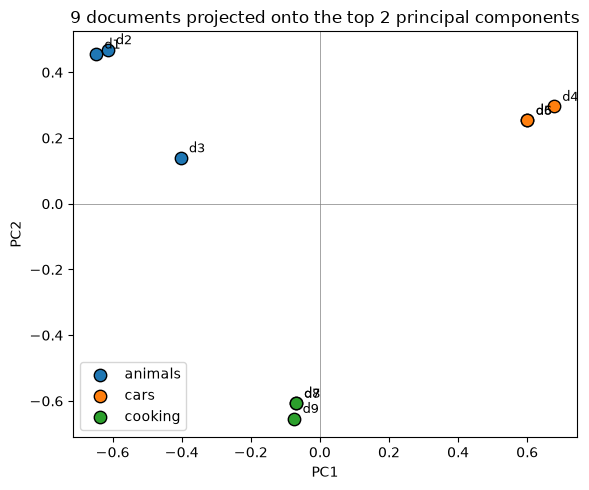

In [7]:
import matplotlib.pyplot as plt

colors = {"animals": "tab:blue", "cars": "tab:orange", "cooking": "tab:green"}
fig, ax = plt.subplots(figsize=(6, 5))
for topic in ["animals", "cars", "cooking"]:
    idxs = [i for i, l in enumerate(LABELS) if l == topic]
    ax.scatter(X_reduced[idxs, 0], X_reduced[idxs, 1], label=topic,
               color=colors[topic], s=80, edgecolor="black")
for i in range(len(CORPUS)):
    ax.annotate(f"d{i+1}", (X_reduced[i, 0], X_reduced[i, 1]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("9 documents projected onto the top 2 principal components")
ax.legend()
plt.tight_layout()
_savefig_to_namespace()

### C.3 What the top components actually mean (loadings)

The eigenvector for each component tells us which original words it
weights most heavily.

In [8]:
for pc_idx in range(2):
    loadings = result["eigenvectors"][:, pc_idx]
    order = np.argsort(-np.abs(loadings))[:5]
    top = ", ".join(f"{vocab[j]} ({loadings[j]:+.3f})" for j in order)
    print(f"PC{pc_idx+1}: {top}")

PC1: car (+0.418), highway (+0.327), engine (+0.327), cat (-0.323), dog (-0.323)
PC2: tomato (-0.349), fresh (-0.349), sauce (-0.349), dog (+0.279), cat (+0.279)


* **PC1** is dominated by `car`, `highway`, `engine` on the positive
  side and `cat`, `dog` on the negative side -- i.e. PC1 is essentially
  a "cars vs. animals" axis.
* **PC2** is dominated by `tomato`, `fresh`, `sauce` on the negative
  side and `dog`, `cat` on the positive side -- i.e. PC2 is essentially
  a "cooking vs. animals/cars" axis.

This matches the corpus by construction, and illustrates why PCA is
useful for word embeddings in general: the reduced axes are not
arbitrary -- they are the directions along which word usage actually
varies the most across documents, so they tend to align with
human-interpretable structure like topic.

---

## Summary

1. **TF-IDF** turns each document into a vector by weighting each word
   by how often it appears in that document (`TF`) and how rare it is
   across the whole corpus (`IDF`), producing a `(documents x
   vocabulary)` matrix.
2. **PCA** reduces the dimensionality of that matrix while preserving
   as much variance as possible by: (1) centering the data on its
   mean, (2) computing the covariance matrix of the centered data, (3)
   finding that matrix's eigenvalues/eigenvectors, (4) sorting them by
   eigenvalue so the most-informative directions come first, and (5)
   projecting the data onto the top $k$ eigenvectors.
3. On the 9-document, 3-topic worked example, reducing from 27
   dimensions to 2 preserved most of the total variance and was enough
   to fully separate the three topics -- demonstrating that a small
   number of principal components can capture most of the meaningful
   structure in a much higher-dimensional word embedding.

---

## Citations / References

* Manning, C. D., Raghavan, P., & Schuetze, H. (2008). *Introduction to
  Information Retrieval*, Chapter 6 (scoring, term weighting, and the
  vector space model / TF-IDF). Cambridge University Press.
  https://nlp.stanford.edu/IR-book/
* Jolliffe, I. T., & Cadima, J. (2016). "Principal component analysis:
  a review and recent developments." *Philosophical Transactions of
  the Royal Society A*, 374(2065). (Overview of PCA: mean-centering,
  covariance matrix, eigendecomposition.)
* scikit-learn documentation, `TfidfVectorizer` (smoothed IDF formula
  used above) and `sklearn.decomposition.PCA`:
  https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
* NumPy documentation, `numpy.linalg.eigh` (symmetric/Hermitian
  eigensolver used for the covariance matrix):
  https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html